# Знакомство с PyTorch


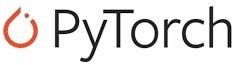

**PyTorch** — фреймворк глубинного обучения для языка Python с открытым исходным кодом.

Фреймворк создан на базе Torch, библиотеки для языка Lua, которая предназначена для математических расчетов и машинного обучения. Используется для решения различных задач: компьютерное зрение, обработка естественного языка.  

Также вокруг этого фреймворка выстроена экосистема, состоящая из различных библиотек, разрабатываемых сторонними командами: PyTorch Lightning и Fast.ai, упрощающие процесс обучения моделей, Pyro (модуль для вероятностного программирования), Flair для обработки естественного языка и Catalyst для обучения DL- и RL-моделей.



Небольшой экскурс по фреймворкам для глубокого обучения:

- **Caffee, Theano, Lasagne** — уже практически не используются;
- **Tensorflow** — фреймворк от Google, который был популярен до 2017-2018 года перед появлением PyTorch. В то время большинство кода, связанного с нейросетями, писалась на нем. Однако он был довольно сложен, поэтому PyTorch быстро перехватил лидерство.

    У Tensorflow есть также "обертка" Keras, которая позволяет более просто работать с нейросетями. Однако Keras менее гибок, чем PyTorch, поэтому не может полноценно его заменить.

    Также в 2019 году вышел Tensorflow 2.0, в котором работа с нейросетями была сильно упрощена. Но к тому моменту рынок уже захватил PyTorch, поэтому Tensorflow 2.0 популярен так и не стал.

- **PyTorch**;
- **JAX** — новый фреймворк от Google, призванный заменить Tensorflow.

**Преимущества PyTorch**

1.  **Гибкость**  
Фреймворк позволяет создавать сложные модели и решать разнообразные задачи. Это возможно благодаря прямому доступу к математическим функциям и возможности писать собственные.

2. **NumPy-подобный интерфейс**  
Некоторые функции и возможности PyTorch напоминают таковые у NumPy, хотя PyTorch мощнее и функциональнее. Тем не менее проекты на NumPy легко конвертировать в формат PyTorch — и наоборот. Тензоры и другие сущности в этих двух инструментах похожи структурой: достаточно немного их изменить для полноценной конвертации.

3. **Автоматическое дифференцирование**  PyTorch умеет автоматически считать градиенты всех вычислений, независимо от количества операций.
Можно учить модели произвольного размера.

4. **Легкое внесение изменений**  
Благодаря динамическому построению графа вычислений PyTorch лишен недостатков, которые есть у некоторых альтернативных вариантов. Вносить изменения в граф можно «на лету», это упрощает отладку и переписывание нейронной сети при необходимости.

5. **Поддержка CUDA и инструменты для оптимизации**  
Все вычисления на PyTorch без головной боли можно перенести на GPU и получить прирост в скорости.

## Начало работы

In [ ]:
# !pip install torch

In [ ]:
import torch
import numpy as np

In [ ]:
print(torch.__version__)

2.11.0+cu128


In [ ]:
RANDOM_STATE = 42

In [ ]:
torch.manual_seed(RANDOM_STATE);

In [ ]:
torch.cuda.is_available()

True

<details>
<summary>Локальная установка</summary>

Ваш ноутбук или сервер должны иметь видеокарту, и `pytorch` должен "увидеть" ее.

Сначала устанавливаем пакет `pytorch` (в виртуальном окружении):

```bash
pip install torch
```

Затем открываем интерпретатор Python и выполняем:
```python
import torch
torch.cuda.is_avaliable()
```

Если выдало `True`, то `pytorch` увидел вашу видеокарту и может работать с ней.
Если выдало `False` или ошибку, то идем читать [официальную инструкцию](https://pytorch.org/get-started/locally/) по установке - в ней описано, как установить `pytorch` так, чтобы он "видел" видеокарту.
Если же и инструкция не помогла, то работаем в облаке — Google Colab или Kaggle Notebooks.

</details>

## Справка



*   Оператор `?`
*   Оператор `??`
*   [Официальная документация](https://pytorch.org/tutorials/)



In [ ]:
torch.nn.functional.mse_loss?

In [ ]:
torch.nn.functional.mse_loss??

## Тензор

**Тензор** — это объект линейной алгебры, линейно преобразующий одно пространство в другое. Частными случаями тензора являются скаляры (тензоры нулевого ранга), векторы (тензоры первого ранга), матрицы (тензоры второго ранга) и т. д.

Тензоры являются ключевыми компонентами PyTorch. Можно сказать, что PyTorch полностью основан на тензорах.

Если вы знакомы с NumPy, вы обнаружите, что тензоры PyTorch похожи на ndarrays в NumPy. Ключевое отличие заключается в том, что они поддерживают CUDA и созданы для запуска на аппаратных ускорителях, таких как графические процессоры.

Еще одна важная особенность тензоров заключается в том, что они оптимизированы для автоматического дифференцирования.

*  Тензор с размерностью `1` — это вектор, список чисел

*  Тензор с размерностью `2` — это матрица, то есть список списков чисел

*  Тензор с размерностью `3` и больше — это тензор, то есть список списков списков (и т.д.) чисел

## Создание тензоров

В PyTorch тензоры могут определяться несколькими способами

In [ ]:
"""
Есть много способов создать тензор в torch.
Посмотрим на некоторые из них.
"""

# Самый простой — запросить тензор определенной размерности

t = torch.Tensor(2, 3, 4)

# Будет заполнен произвольными непредсказуемыми данными
t

tensor([[[-3.2459e+03,  4.5006e-41, -3.2459e+03,  4.5006e-41],
         [-1.7841e+03,  4.5006e-41,  1.5070e-38,  0.0000e+00],
         [-1.7841e+03,  4.5006e-41,  1.5070e-38,  0.0000e+00]],

        [[-1.7842e+03,  4.5006e-41,  1.5066e-38,  0.0000e+00],
         [ 1.5065e-38,  0.0000e+00,  1.5065e-38,  0.0000e+00],
         [-1.7841e+03,  4.5006e-41,  1.5067e-38,  0.0000e+00]]])

In [ ]:
# Можно спросить, какой размер. Помним, что было (2, 3, 4)
t.size()

torch.Size([2, 3, 4])

In [ ]:
# Есть .shape — работает аналогично
t.shape

torch.Size([2, 3, 4])

In [ ]:
# shape можно удобно сравнивать с tuple — пригодится в тестах
assert t.shape == (2, 3, 4)

In [ ]:
# В torch много функций для самых "ходовых" тензоров.
# Например, создать тензор из нулей
# Сделаем матрицу (5, 3), заполненную нулями
torch.zeros((5, 3))

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [ ]:
# Тензор (2, 3, 4), все числа равны 1.
# Обратите внимание на точку после 1. — это значит, что тип float
t = torch.ones((2, 3, 4))
t

tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

In [ ]:
# А если точнее — float32.
t.dtype

torch.float32

In [ ]:
# аналогично можно заполнить любыми числами:
2.7 * torch.ones((3, 2, 4))

tensor([[[2.7000, 2.7000, 2.7000, 2.7000],
         [2.7000, 2.7000, 2.7000, 2.7000]],

        [[2.7000, 2.7000, 2.7000, 2.7000],
         [2.7000, 2.7000, 2.7000, 2.7000]],

        [[2.7000, 2.7000, 2.7000, 2.7000],
         [2.7000, 2.7000, 2.7000, 2.7000]]])

Обратите внимание на квадратные скобки.
По ним видно, что тензор как будто состоит из двух матриц 3x4, соединенных вместе.

In [ ]:
# Тензор (2, 3, 2, 4), каждый элемент взят из стандартного нормального распределения
torch.randn((2, 3, 2, 4))

tensor([[[[-0.1759, -0.9836,  0.0832,  0.6781],
          [ 0.2782,  1.5340,  1.4039, -0.1062]],

         [[ 0.6599, -0.5476, -0.5193, -1.1024],
          [-0.6806,  0.2798,  0.0763,  0.1178]],

         [[-0.5659, -2.5985,  0.0781, -0.4678],
          [ 0.8224,  1.0466, -0.5201, -0.5892]]],


        [[[-0.2270,  0.2979, -1.3967, -0.5411],
          [-1.0385, -0.6904, -1.3431, -0.7150]],

         [[-1.5536,  0.6463,  0.4875, -0.4545],
          [ 0.2617, -0.7935,  0.0833,  0.3051]],

         [[-0.1007, -0.7251, -0.0665, -0.6865],
          [ 0.7199,  0.0902, -0.1834,  0.7368]]]])

In [ ]:
torch.randn??

### in-place операции

Все рассмотренные ранее операции создают **новый** тензор.
Но иногда хочется не создавать новый, а менять существующий.

Для этого есть т.н. "in-place" ("на месте") операции — они меняют тот тензор,
над которым применяются, и не создают никаких других тензоров.

In [ ]:
# Создадим тензор из единиц
t = torch.ones((2, 3))
t

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [ ]:
# И занулим его. Обратите внимание на нижнее подчеркивание.
t.zero_()
t

tensor([[0., 0., 0.],
        [0., 0., 0.]])

В torch все in-place операции строятся как обычные с нижним подчеркиванием (`_`) в конце.

In [ ]:
print(t)
t.random_()
print(t)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[12648521.,  3275686.,    84453.],
        [ 5147423.,  1954303., 15271690.]])


In-place операции позволяют сэкономить память, т.к. создаем в два раза меньше тензоров.
У этого есть обратная сторона: если мы передаем тензор в функцию, то функция может
этот тензор "испортить", поменяв его in-place.

Посмотрим на примере:

In [ ]:
def random_like(a: torch.Tensor) -> torch.Tensor:
    """Создать случайный тензор того же размера, что и `a`."""
    # перезатираем `a` - это не очень хорошо
    return a.random_(0, 5)


zero_tensor = torch.zeros((2, 3))
print("zero_tensor до функции:")
print(zero_tensor)

random_tensor = random_like(zero_tensor)
print("Рандомный тензор того же размера:")
print(random_tensor)

print("zero_tensor после функции:")
print(zero_tensor)

zero_tensor до функции:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
Рандомный тензор того же размера:
tensor([[1., 4., 0.],
        [4., 3., 3.]])
zero_tensor после функции:
tensor([[1., 4., 0.],
        [4., 3., 3.]])


In [ ]:
# без перезатирания
def random_like(a: torch.Tensor) -> torch.Tensor:
    return torch.randint(0, 5, a.shape, dtype=torch.float32)
    # еще можно одной строкой
    # return torch.randint_like(a, 0, 5)
    # у многих функций есть _like аналоги: zero_like, ones_like


zero_tensor = torch.zeros((2, 3))
print("zero_tensor до функции:")
print(zero_tensor)

random_tensor = random_like(zero_tensor)
print("Рандомный тензор того же размера:")
print(random_tensor)

print("zero_tensor после функции:")
print(zero_tensor)

zero_tensor до функции:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
Рандомный тензор того же размера:
tensor([[1., 0., 0.],
        [0., 0., 1.]])
zero_tensor после функции:
tensor([[0., 0., 0.],
        [0., 0., 0.]])


## Операции с тензорами

Большинство функций, которые есть в NumPy над матрицами,
есть и в PyTorch над тензорами.
Рассмотрим самые популярные из этих функций:
- сложение, умножение, вычитание, деление;
- матричное умножение;
- обращение тензора;

Также разберем нетривиальные моменты.

In [ ]:
# Тензоры можно возводить в степень, умножать друг на друга.
# Это будет поэлементно!
# Вообще, большинство арифметических операций в pytorch выполняются поэлементно.
# Это +, -, *, /
a = torch.arange(4).reshape((2, 2))
b = torch.arange(4, 8).reshape((2, 2))

print("Поэлементное умножение:")
print(a * b)

print("То же самое, что '*':")
print(a.mul(b))

print('То же самое, что "+", есть inplace-версия a.add_(b):')
print(a.add(b))

print("Возвести в квадрат поэлементно:")
print(a**2)

print("Обратите внимание: в математической литературе A^2 - это не поэлементно")
print("В матем. литературе обычно под A^2 подразумевают следующее:")
print(a @ a)
print(a.matmul(a))
print()

print("В частности, обратную матрицу надо считать вот так:")
print(a.float().inverse())  # приводим к float, т.к. inverse работает только с ним

print("Но вот a**(-1) лишь каждый элемент обратит:")
print(a.float() ** (-1))  # pytorch не дает обращать integer элементы тензора

Поэлементное умножение:
tensor([[ 0,  5],
        [12, 21]])
То же самое, что '*':
tensor([[ 0,  5],
        [12, 21]])
То же самое, что "+", есть inplace-версия a.add_(b):
tensor([[ 4,  6],
        [ 8, 10]])
Возвести в квадрат поэлементно:
tensor([[0, 1],
        [4, 9]])
Обратите внимание: в математической литературе A^2 - это не поэлементно
В матем. литературе обычно под A^2 подразумевают следующее:
tensor([[ 2,  3],
        [ 6, 11]])
tensor([[ 2,  3],
        [ 6, 11]])

В частности, обратную матрицу надо считать вот так:
tensor([[-1.5000,  0.5000],
        [ 1.0000,  0.0000]])
Но вот a**(-1) лишь каждый элемент обратит:
tensor([[   inf, 1.0000],
        [0.5000, 0.3333]])


## Градиенты в PyTorch
Вторая причина популярности PyTorch: удобная работа с производными операций.

PyTorch умеет считать градиенты автоматически.
Вы делаете любое вычисление, например:
```python
result = my_matrix ** 2
# затем
result.backward()
```
Более подробная [документация](https://pytorch.org/docs/stable/notes/autograd.html).

### Пример

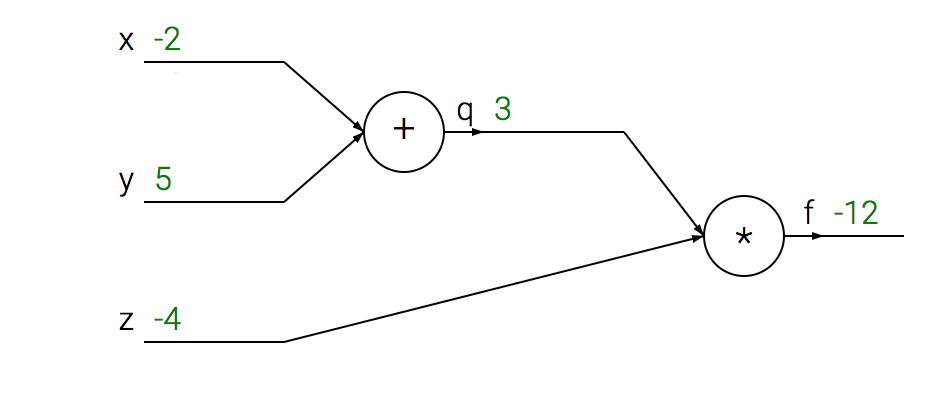

$f(x, y, z) = (x + y) \cdot z$  

$\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}, \frac{\partial f}{\partial z}$

In [ ]:
x = torch.tensor(-2., requires_grad=True)
y = torch.tensor(5., requires_grad=True)
z = torch.tensor(-4., requires_grad=True)

q = x + y
f = q * z

In [ ]:
f.backward()

In [ ]:
print(f'df/dz = {z.grad}')
print(f'df/dy = {y.grad}')
print(f'df/dx = {x.grad}')

df/dz = 3.0
df/dy = -4.0
df/dx = -4.0


In [ ]:
# requires_grad=True означает, что мы хотим считать градиент по всем элементам тензора
w = torch.tensor([[1, 1], [2, 2]], dtype=float, requires_grad=True)
x = torch.tensor([[5], [3]], dtype=float)
print(w)

final_answer = w @ x
print(final_answer)

one_scalar = final_answer.sum()
one_scalar.backward()
print(w.grad)

# градиент можно брать только от скаляров, следующая строка не сработает:
# final_answer.backward()

tensor([[1., 1.],
        [2., 2.]], dtype=torch.float64, requires_grad=True)
tensor([[ 8.],
        [16.]], dtype=torch.float64, grad_fn=<MmBackward0>)
tensor([[5., 3.],
        [5., 3.]], dtype=torch.float64)


А теперь вручную считаем:
$$
    \begin{bmatrix}
        w_{11} & w_{12} \\
        w_{21} & w_{22}
    \end{bmatrix}
    \begin{bmatrix}
        x_1 \\
        x_2
    \end{bmatrix}
    = \begin{bmatrix}
        w_{11} x_1 + w_{12} x_2 \\
        w_{21} x_1 + w_{22} x_2
    \end{bmatrix}
    \xrightarrow{\sum}
    w_{11} x_1 + w_{12} x_2 + w_{21} x_1 + w_{22} x_2
$$
отсюда видим, что
$$
\frac{\partial L}{\partial w_{11}} = x_1; \quad
\frac{\partial L}{\partial w_{12}} = x_2; \quad
\frac{\partial L}{\partial w_{21}} = x_1; \quad
\frac{\partial L}{\partial w_{22}} = x_2; \quad
$$
Смотрим на числа выше и убеждаемся, что градиент был подсчитан верно.

In [ ]:
# Градиент не будет работать без requires_grad=True
a = torch.tensor([1.0, 2.0])
try:
    torch.sum(a).backward()
except RuntimeError as e:
    print(e)

element 0 of tensors does not require grad and does not have a grad_fn


## Нейронная сеть на PyTorch

Давайте научимся создавать полносвязную нейросеть на PyTorch.

Нейронные сети в Pytorch создаются по типу конструктора: есть набор стандартных блоков из которых мы можем собрать итоговую модель. Простейшие из этих блоков — линейные слои и функции активации. В следующих занятиях мы познакомимся с новыми блоками, которые можно встраивать в архитектуру сети.

Давайте вспомним, как устроена полносвязная нейросеть.



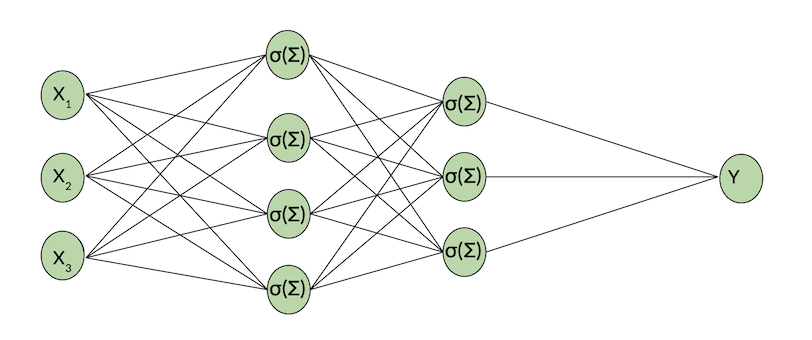


$$\widehat{y} = \sigma(W_3^T \sigma(W_2^T \sigma(W_1^TX + b_1 ) + b_{2}) + b_{3})$$

Каждый полносвязный слой представляет из себя комбинацию линейного преобразования $\widehat{c} = WX + b$ и некоторой функции активации $\sigma(\widehat{c})$:
- Сначала входящий вектор $X$ умножается на матрицу $W$ и к результату прибавляется вектор смещения $b$:
    
    $$\widehat{c} = WX + b$$
- Далее полученный результат прогоняется через функцию активации. Полученный результат подается в качестве входного вектора следующему слою сети.
    $$\sigma(\widehat{c})$$

Нейросеть задается как список подобных преобразований, следующих друг за другом.

Давайте научимся задавать линейное преобразование и функцию активации. А затем скомбинируем их для создания полносвязной нейросети.

Слой, представляющий из себя линейное преобразование задаётся при помощи класса `torch.nn.Linear`. Давайте создадим слой с 5 входными и 3 выходными нейронами.

In [ ]:
import torch.nn as nn

n = 5
m = 3
linear_layer = nn.Linear(n, m)

In [ ]:
linear_layer

Linear(in_features=5, out_features=3, bias=True)

Далее — функция активации. Многие известные функции активации реализованы в модуле `nn` и продублированы в модуле `nn.functional`. Выберем какую-нибудь из них, например, гиперболический тангенс (tanh).

In [ ]:

import torch.nn.functional as F

# Можно использовать такой вариант
# activation = F.tanh
# или более правильный вариант:
activation = nn.Tanh()

In [ ]:
x_tensor = torch.tensor([
    [1, 2],
    [3, 4]
])

activation(x_tensor)

tensor([[0.7616, 0.9640],
        [0.9951, 0.9993]])

**Замечание:** второй вариант объявления функции активации (с помощью модуля nn) более предпочителен, т.к. использование функций напрямую из `torch.nn.functional` иногда может приводить к не вполне корректной работе сложных моделей. Безопаснее и правильнее использовать именно классы из `torch.nn`, однако очень часто на раличных ресурсах, посвященных  `Pytorch`, можно встретить использование объектов из `torch.nn.functional`, поэтому мы считаем нужным рассказать и о таком способе использования функций активации.

Теперь проход некоторого тензора с данными через такой полносвязный слой будет задан при помощи последовательности команд:

In [ ]:
random_input = torch.rand(5)

z = linear_layer(random_input)
output = activation(z)
output

tensor([-0.6701,  0.2566,  0.6032], grad_fn=<TanhBackward0>)

Обратим внимание на `grad_fn=<TanhBackward0>`. Подобная приписка будет появляться на всех тензорах, которые являются обучающими параметрами в нейросети. Это значит, что для данного тензора в процессе обучения сети будет вычисляться градиент, с помощью которого значения тензора будут обновляться. Подробнее про процесс обучения сети мы поговорим далее в этом уроке.

Давайте теперь соберем нейросеть из блоков Linear и Tanh. Самый простой способ объединить несколько модулей в цепочку - это использование модуля `nn.Sequential`. Этот класс позволит нам объединить несколько модулей в один контейнер так, что в случае применения этого контейнера к некоторму тензору, вычисления будут проведены в том порядке, в котором мы передали элементы. То есть, так мы сможем получить нейросеть с последовательными слоями Linear и Tanh.

In [ ]:
FF_layer = nn.Sequential(
    linear_layer,
    activation
)

FF_layer(random_input)

tensor([-0.6701,  0.2566,  0.6032], grad_fn=<TanhBackward0>)

Мы получили точно такой же результат, как и в ячейке выше. Давайте теперь таким же образом построим полносвязную нейросеть для решения какой-нибудь простой задачи. Например, попробуем смоделировать функцию косинуса.

### Полносвязная нейросеть для приближения функции косинуса

Прежде всего зададим одномерный датасет.

In [ ]:
X = torch.normal(mean=torch.zeros((1000, 1)), std= 2)
Y = torch.cos(X)

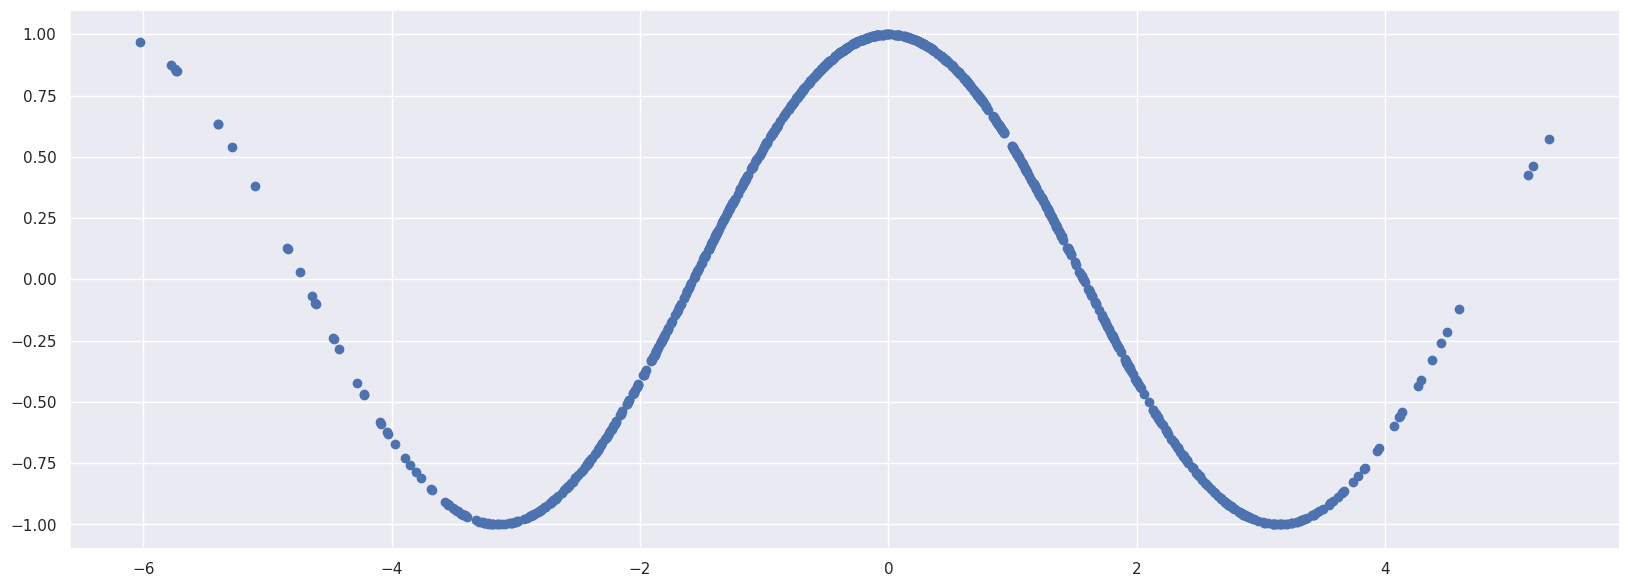

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

plt.figure(figsize=(20,7))
plt.scatter(x=X, y=Y);

Давайте зададим нейронную сеть с тремя слоями. Пусть в скрытых слоях будет пять нейронов. В качестве функции активации выберем гиперболический тангенс, как и в примерах выше.

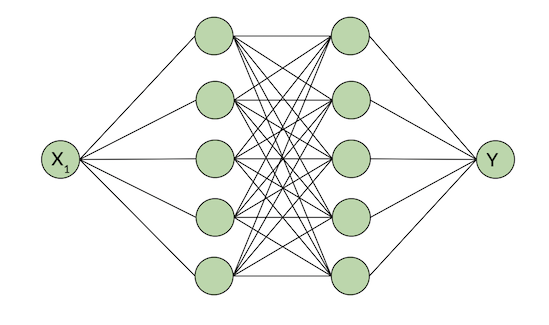

In [ ]:
import torch.nn as nn

NN = nn.Sequential(
    nn.Linear(1, 5, bias=True),
    nn.Tanh(),
    nn.Linear(5, 5, bias=True),
    nn.Tanh(),
    nn.Linear(5, 1, bias=True),
    nn.Tanh()
    )

Посмотрим, что умеет наша необученная нейросеть:

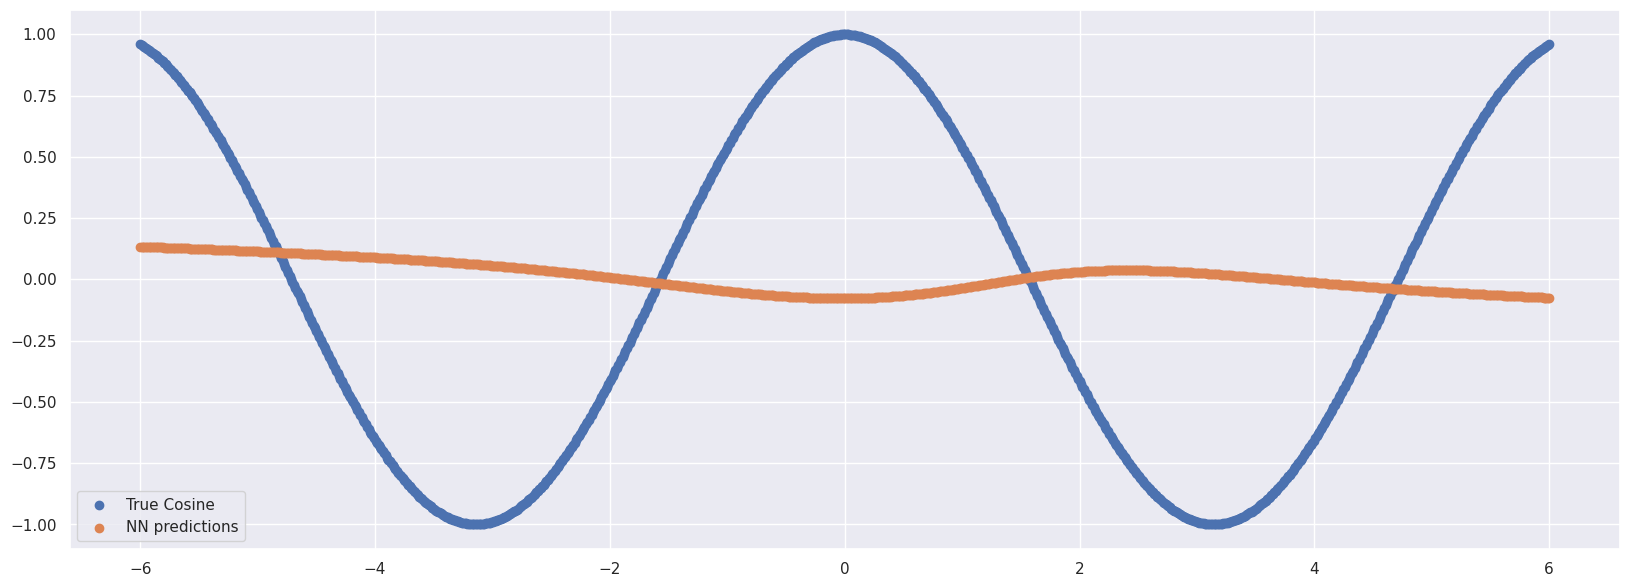

In [ ]:
X_test = torch.linspace(-6, 6, 1000)
Y_test = torch.cos(X_test)

nn_prediction = NN(X_test.view(-1, 1))
nn_prediction = nn_prediction.detach().numpy()

plt.figure(figsize=(20,7))
plt.scatter(x=X_test, y=Y_test, label='True Cosine');
plt.scatter(x=X_test, y=nn_prediction, label='NN predictions');
plt.legend();

Полученный результат ожидаем, поскольку наша нейронная сеть не обучена. Давайте обучим её. Но сначала поговорим о том, как вообще это можно сделать.


**Замечание 1:** в 4 строке предыдущей ячейки мы воспользовались функцией `.view()`. `.view()` - это альтернатива функции `.reshape()`, позволяющая изменить размерность тензора без изменения данных в нём. Здесь мы применили её для того, чтобы сделать из вектора входных данных длины $n$ матрицу размера $(n, 1)$. Эта формальность необходима для корректного прохода тензора через наши преобразования. Дело в том, что нейросеть (и любые другие модели машинного обучения) принимают на вход данные в виде матрицы размера $(n, k)$, где $n$ — количество элементов данных, $k$ — количество признаков у каждого элемента данных. У нас же у каждого элемента 1 признак (его координата по оси ОХ). И мы как бы делаем матрицу элементы-признаки, в которой $n$ элементов, и у каждого элемента 1 признак.

**Замечание 2:** в 5 строке мы выполнили комбинацию методов тензора `.detach().numpy()`. Функция `.detach()` нужна для извлечения тензора из графа вычислений нейросети. Грубо говоря, выход нейросети все еще является частью графа вычислений сети, и чтобы перевести этот тензор в numpy, нужно сначала отделить его от графа сети.

## Обучение нейронных сетей



Нейронные сети обучаются при помощи алгоритма градиентной оптимизации. Идея таких алгоритмов основана на последовательном вычислении градиентов (частных производных) лосс-функции по весам сети и обновлении весов сети.

Сейчас мы последовательно разберем идею алгоритма градиентной оптимизации.


Вспомним для начала, что наша цель при обучении нейросети — подобрать такие гиперпараметры сети, чтобы среднее значение выбранной лосс-функции было минимально в среднем на обучающем датасете.

Пусть мы выбрали лосс-функцию $L$, которую мы хотим минимизировать на наших данных.

Тогда задача обучения сети — найти такие параметры сети $W_1, b_1, W_2, b_2, \dots$, что среднее значение лосс-функции на элементах тренировочного датасета минимально: $$loss = \frac{\sum_{i=1}^n L(y_i, \widehat{y}_i)}{n} \to min$$

, где $n$ — количество элементов в данных, $y_i$ — верное значение целевой переменной для $i$-ого элемента данных,  $\widehat{y}_i$ — ответ модели для $i$-ого элемента данных.

Давайте еще раз посмотрим на нейросеть и поймем, что ее формулу можно рассматривать как функцию от ее параметров ($W_i$ и $b_i$)

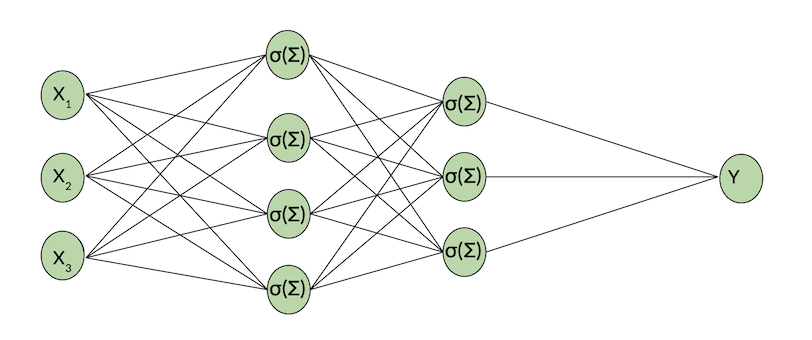

$$\widehat{y} = \sigma(W_3^T \sigma(W_2^T \sigma(W_1^TX + b_1 ) + b_{2}) + b_{3})$$

Подставив эту формулу для $\widehat{y}$ в формулу $loss$, получим:

$$loss = \frac{\sum_{i=1}^n L(y_i, \sigma(W_3 \sigma(W_3^T \sigma(W_1^TX_i + b_1 ) + b_{2}) + b_{3}))}{n} \to min$$

Получается, $loss$ — это функция от параметров сети $W_i$ и $b_i$. И при обучении сети стоит задача минимизации функции многих переменных, т.е. задача нахождения таких значений $W_1, b_1, W_2, b_2, W_3, b_3$, что значение $loss$ для них — минимально.

**Как можно решить задачу минимизации функции?**

Давайте вспомним идею *градиентного спуска*.

Для начала мы разберем способы решения задачи минимизации функции и алгоритм градиентного спуска для функции одной переменной. Затем обобщим его для функций многих переменных.
______________________

### Напоминание: градиентный спуск

#### Минимизация функции одной переменной

Здесь мы поговорим о способах решения задачи минимизации функции одной переменной

Первый способ — аналитический. Для многих функций точку минимума можно найти, приравняв производную к нулю.

$$y = x^3 - 3x - 4$$
$$\frac{dy}{dx} = 3x^2-3$$
$$x_{min} = \{-1, 1\}$$

Однако такой способ работает не для всех функций даже одной переменной. Что уж говорить о функциях многих переменных.

$$y = x^{10} - 3x^7 - 4x^3 + 4x$$
$$\frac{dy}{dx} = 10x^9-21x^6 -12x^2 + 4$$
$$x_{min} = \ ?$$

Здесь нам на помощь приходят два свойства частной производной. Для функции одной переменной эти свойства можно сформулировать так:

1. Знак производной в точке показывает, возрастает или убывает функция в этой точке;
2. Модуль значения производной говорит о скорости роста/убывания функции в точке. Чем выше модуль значения f’(x), тем выше скорость убывания/возрастания функции f в точке х.

Давайте проиллюстрируем эти свойства. Рассмотрим функцию одной переменной $$f(x) = x^4 + 5x^3 - 10x$$

Ее производная:
$$\frac{df}{dx} = 4x^3 + 15x^2 - 10$$

Посчитаем значение производной в точках -5, -3.55, -2:

$$\frac{df}{dx}(-5) = -135$$
$$\frac{df}{dx}(-3.55) = ~0$$
$$\frac{df}{dx}(-2) = 18$$

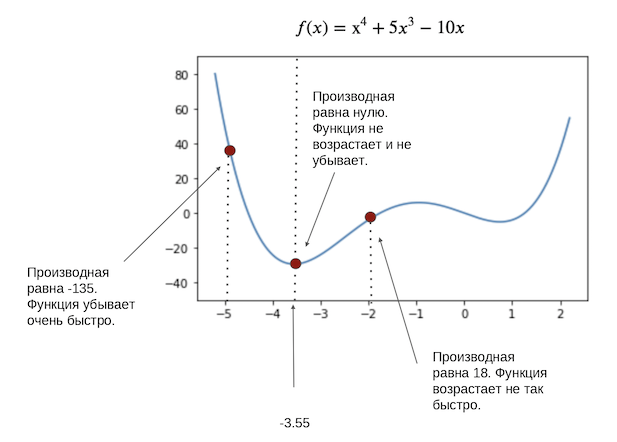

Получается, **вычислив производную функции в точке $x$, мы знаем, в какую сторону нужно сдвинуться от точки $x$, чтобы значение функции уменьшилось**.

Это свойство мы можем использовать для поиска минимума функции. Идея возникает такая: давайте выберем случайную точку, например, $x=5$. Вычислим значение производной функции в этой точке. По знаку производной поймем, куда надо сдвинуться, чтобы прийти в точку минимума. И будем туда двигаться.

Однако есть проблема: мы знаем, в какой стороне лежит точка минимума, но не знаем, насколько она далеко. То есть, мы не знаем, на сколько нужно сдвинуться от текущей точки, чтобы прийти в точку минимума.

Можно пытаться делать так: зафиксировать величину шага, скажем, $\delta x = 1$. Выбрать случайную точку, например, $x=5$. Вычислить значение производной функции в этой точке. По знаку производной понять, куда надо сдвинуться, чтобы прийти в точку минимума. Сдвинуться в этом направлении на величину шага $\delta x$. В новой точке снова вычислить значение производной функции. Снова понять, куда теперь надо сдвинуться, чтобы прийти в точку минимума. Сдвинуться туда на $\delta x$. И т.д.

Но такая идея довольно неэффективна. На то есть минимум две причины:
1. Иногда начальная точка настолько далеко от точки минимума, что чтобы дойти до точки минимума, придется сделать очень большое количество шагов;
2. Иногда начальная точка (или точка, в которую мы пришли в течение алгоритма) настолько близко к точке минимума, что при шаге в величину $\delta x = 1$ мы "перепрыгнем" через точку минимума.



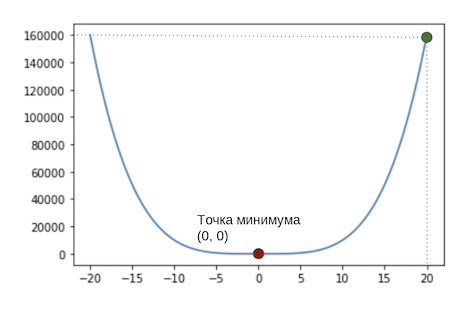

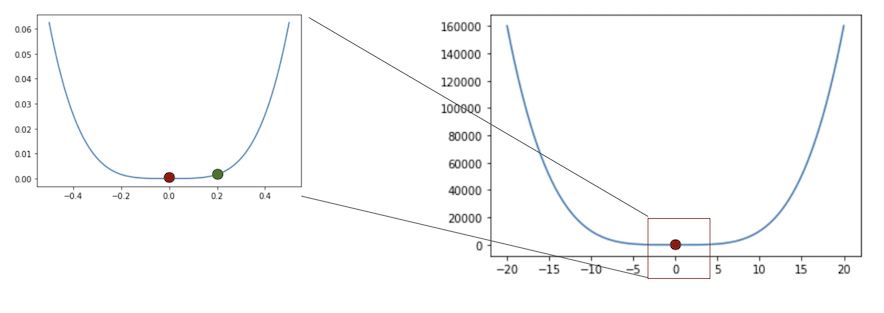

Тут нам поможет второе упомянутое свойство производной: что модуль значения производной говорит о скорости роста/убывания функции в точке. Идея тут тогда такая: давайте каждый раз сдвигаться не на $\delta x = 1$, а на $\delta x = alpha*\frac{df}{dx}$. Тогда мы будем двигаться на больший шаг, когда мы будем далеко от точки минимума, и на меньший шаг, если будем близко к точке минимума.

Тогда **алгоритм градиентного спуска для функции одной переменной** будет выглядеть так:

1. Выбираем случайную начальную точку $x$. Выбираем значение шага градиентного спуска $\alpha$
2. Пока не будет выполнен критерий остановки, делаем следующее:
    - вычисляем значение $f(x)$ для текущей точки $x$;
    - вычисляем значения производной $\frac{d f}{d x}$;
    - двигаемся к новой точке:
    $$x = x - \alpha \frac{df}{dx}$$

Критерий остановки может быть разным. Например, если значение производной в текущей точке (и, соответственно, шаг градиентного спуска) стало очень малым.

#### Минимизация функции многих переменных

Для функции двух и более переменных частные производные по каждой из переменных имеют те же свойства:

1. Знак частной производной по переменной $x_1$ в точке показывает, возрастает или убывает функция в этой точке *по переменной $x_1$*;
2. Модуль значения частной производной по переменной $x_1$ говорит о скорости роста/убывания функции в точке *по переменной $x_1$*. Чем выше модуль значения $f’_{x_1}(x)$, тем выше скорость убывания/возрастания функции f *по переменной $x_1$* в точке х.

Например, рассмотрим функцию двух переменных $$f(x_1, x_2) = 3x_1^2 + 2x_1x_2$$

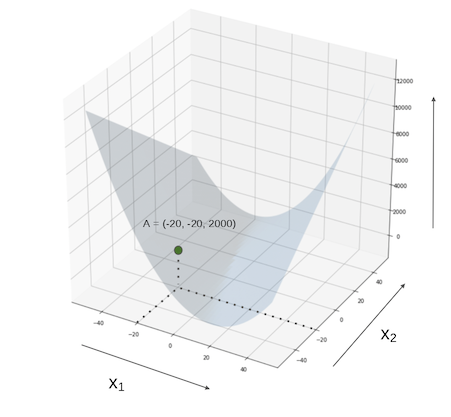

Ее частная производная по $x_1$:
$$\frac{df}{dx_1} = 6x_1 + 2x_2$$
И ее значение в точке x = (-20, -20):
$$\frac{df}{dx_1}(-20, -20) = 6 \cdot (-20) + 2\cdot (-20) = -160$$

Получается, вычислив частную производную функции в точке $x$ по переменной $x_1$, мы знаем, в какую сторону нужно сдвинуться от точки $x$ по переменной $x_1$, чтобы уменьшить значение функции.

Тогда **алгоритм градиентного спуска для функции многих переменной** будет выглядеть так:

1. Выбираем случайную начальную точку $x = (x_1, x_2, ..., x_n)$. Выбираем значение шага градиентного спуска $\alpha$
2. Пока не будет выполнен критерий остановки, делаем следующее:
    - вычисляем значение функции в текущей точке $f(x)$
    - вычисляем значение производной $\frac{d f}{d x_i}(x)$;
    - двигаемся к новой точке:
    $$x_i = x_i - \alpha \frac{df}{dx_i}(x)$$

Алгоритм называется градиентным спуском, потому что вектор частных производных функции $\nabla f = (\frac{df}{dx_1}, \frac{df}{dx_2}, ..., \frac{df}{dx_n})$ называется градиентом функции f. И в шаге номер два происходит обновление градиента:
$$x = x - \alpha \nabla f$$
______________________________

### Обучение нейросети с помощью градиентного спуска

Давайте еще раз посмотрим на формулу нейросети. Мы уже поняли, что формулу лосса для нейросети можно рассматривать как функцию многих переменных от весов сети.

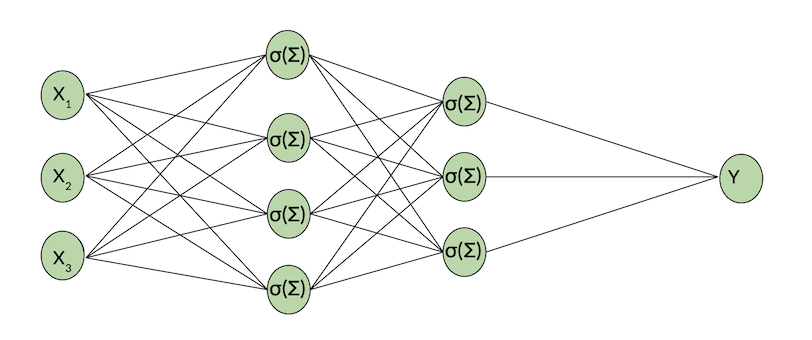

$$\widehat{y} = \sigma(W_3^T \sigma(W_2^T \sigma(W_1^TX + b_1 ) + b_{2}) + b_{3})$$

$$loss = \frac{\sum_{i=1}^n L(y_i, \sigma(W_3 \sigma(W_3^T \sigma(W_1^TX_i + b_1 ) + b_{2}) + b_{3}))}{n} \to min$$

Тогда **алгоритм градиентной оптимизации для нейросети** выглядит следующим образом:

1. Инициализируем все веса сети $W_i$ и $b_i$ случайными значениями. Выбираем значение шага градиентного спуска $\alpha$
2. Пока не будет выполнен критерий остановки, делаем следующее:
    - вычисляем значение $loss$ c текущими значениями параметров $W_i$ и $b_i$;
    - вычисляем значения частных производных $\frac{\partial loss}{\partial W_i}$, $\frac{\partial loss}{\partial b_i}$;
    - обновляем значения параметров сети:
    $$W_i = W_i - \alpha \frac{\partial loss}{\partial W_i}, \ \ b_i = b_i - \alpha \frac{\partial loss}{\partial b_i}$$

Этот алгоритм лежит в основе обучения всех нейросетей, с которыми мы познакомимся в дальнейшем. У него есть много вариаций, улучшающих поведение алгоритма во многих ситуациях, но идея остается той же.

Как именно вычисляются производные $\frac{\partial L}{\partial W_i}$ и $\frac{\partial L}{\partial b_i}$, мы разбирать не будем. Остановимся на том, что вычислить их возможно. Вы можете узнать подробнее о том, как они вычисляются, из дополнительных материалов к ноутбуку. Стоит только сказать, что алгоритм вычисления частных производных $\frac{\partial L}{\partial W_i}$ и $\frac{\partial L}{\partial b_i}$ называется **алгоритмом обратного распространения ошибки**, или **backpropagation**.

А мы перейдем к обучению нашей нейросети для приближения функции косинуса на PyTorch.

### Обучение нейронной сети в PyTorch

Алгоритм вычисления частных производных лосс-функции по весам сети реализован внутри PyTorch. Нам не нужно писать его код.

Давайте напишем функцию `train` для обучения нейронной сети.

In [ ]:
import tqdm
from tqdm.auto import tqdm

def train(model, X, y, criterion, optimizer, num_epoch):
    '''
    args:
        model - модель нейронной сети
        X и y - обучающая выборка
        criterion - функция потерь, взятая из модуля `torch.nn`
        optimizer - оптимизатор, взятый из модуля `torch.optim`
        num_epoch - количество эпох обучения. Т.е. число градиентных шагов,
                    которые будут выполнены для каждого объекта в выборке
    '''

    # цикл по количеству эпох обучения
    for t in tqdm(range(num_epoch)):

        # Вычислим предсказания нашей модели
        y_pred = model(X)

        # Посчитаем значение функции потерь  на полученном предсказании
        loss = criterion(y_pred, y)

        # Обнулим посчитанные ранее значения градиентов
        optimizer.zero_grad()

        # Выполним подсчёт новых градиентов
        loss.backward()

        # Выполним шаг градиентного спуска
        optimizer.step()

    return model

Снова объявим нашу сеть:

In [ ]:
NN = nn.Sequential(
    nn.Linear(1, 5, bias=True),
    nn.Tanh(),
    nn.Linear(5, 5, bias=True),
    nn.Tanh(),
    nn.Linear(5, 1, bias=True)
    )

Объявим лосс-функцию и оптимизатор и обучим сеть на 30 эпохах:

In [ ]:
# лосс-функция
criterion = torch.nn.MSELoss()

# оптимизатор
optimizer = torch.optim.Adam(NN.parameters(), lr=1e-2)

NN = train(NN, X, Y, criterion, optimizer, 30)

  0%|          | 0/30 [00:00<?, ?it/s]

Посмотрим теперь, каков будет результат.

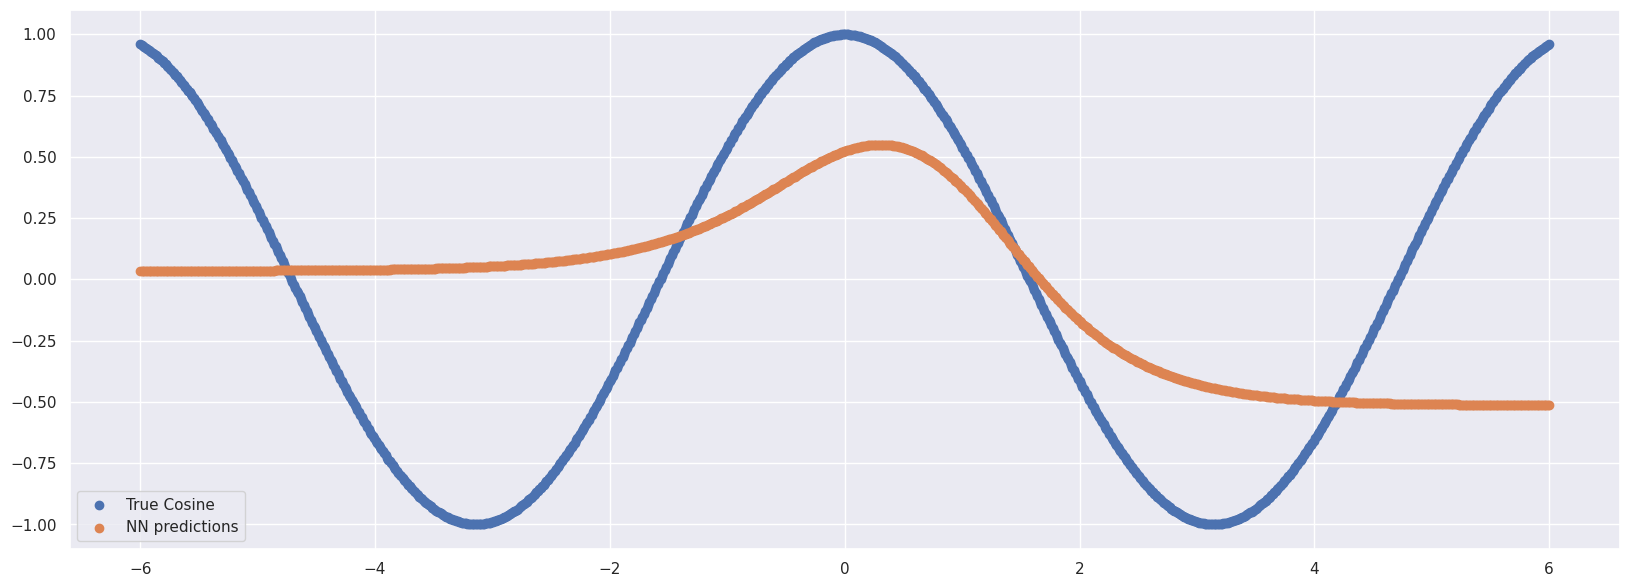

In [ ]:
nn_prediction = NN(X_test.view(-1, 1))
nn_prediction = nn_prediction.detach().numpy()

plt.figure(figsize=(20,7))
plt.scatter(x=X_test, y=Y_test, label='True Cosine');
plt.scatter(x=X_test, y=nn_prediction, label='NN predictions');
plt.legend()

Стало заметно лучше, но явно требуется еще несколько итераций обучения.

In [ ]:
NN = train(NN, X, Y, criterion, optimizer, 15)

  0%|          | 0/15 [00:00<?, ?it/s]

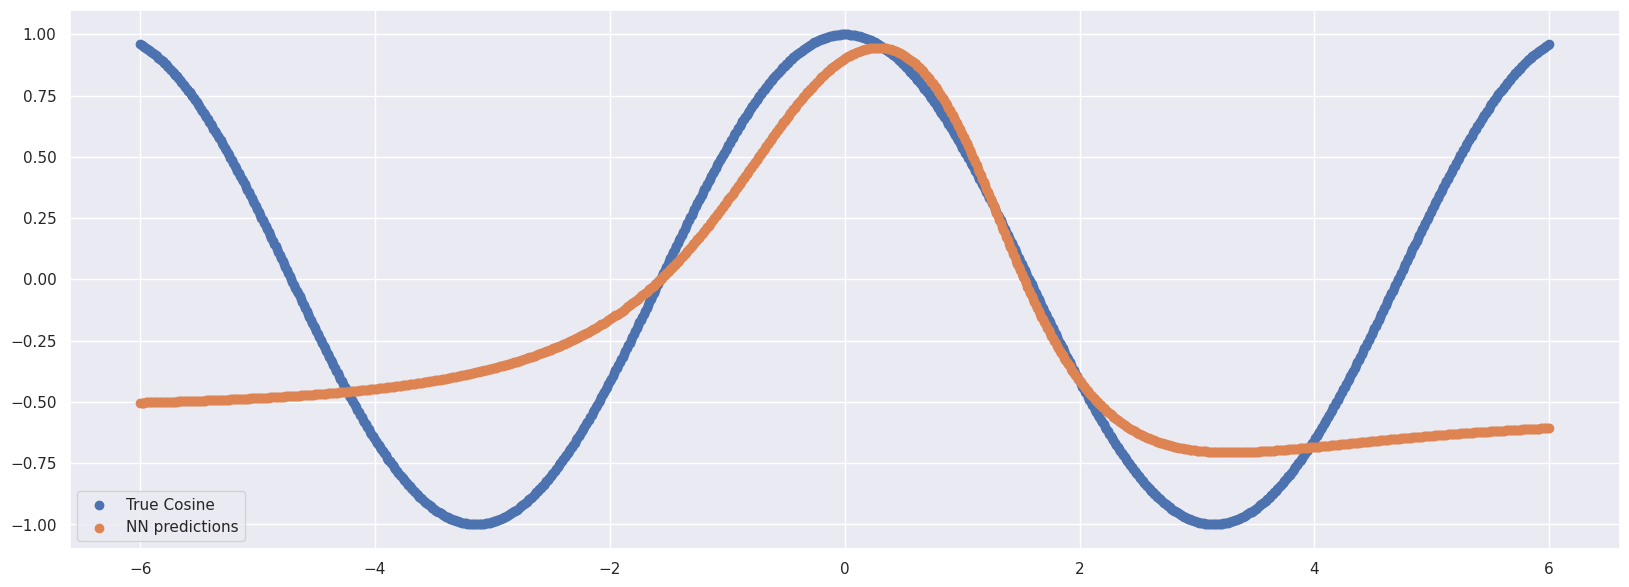

In [ ]:
nn_prediction = NN(X_test.view(-1, 1))
nn_prediction = nn_prediction.detach().numpy()

plt.figure(figsize=(20,7))
plt.scatter(x=X_test, y=Y_test, label='True Cosine');
plt.scatter(x=X_test, y=nn_prediction, label='NN predictions');
plt.legend()

Один из возможных вариантов улучшения сходимости - это уменьшение градиентного шага. Давайте понизим его до 0.001 и выполним еще несколько итераций обучения.

In [ ]:
optimizer = torch.optim.Adam(NN.parameters(), lr=1e-5)

NN = train(NN, X, Y, criterion,optimizer, 50)

  0%|          | 0/50 [00:00<?, ?it/s]

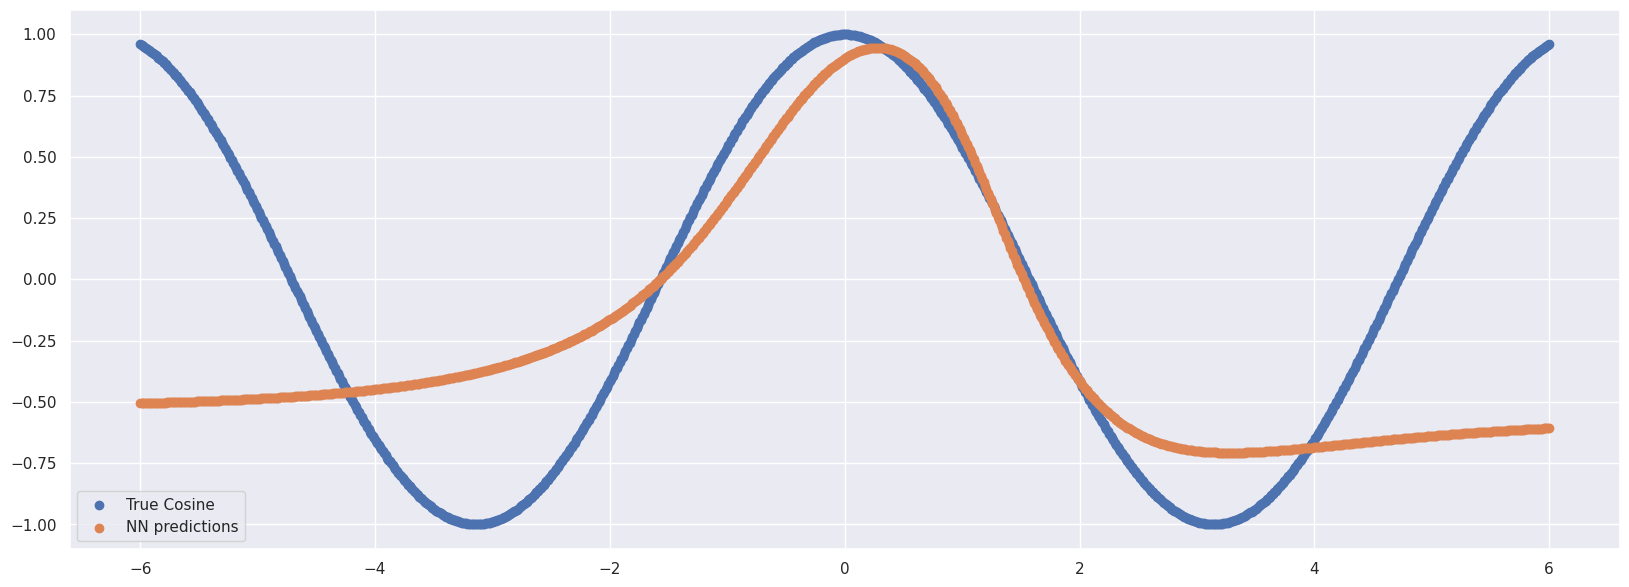

In [ ]:
nn_prediction = NN(X_test.view(-1, 1))
nn_prediction = nn_prediction.detach().numpy()

plt.figure(figsize=(20,7))
plt.scatter(x=X_test, y=Y_test, label='True Cosine');
plt.scatter(x=X_test, y=nn_prediction, label='NN predictions');
plt.legend()

Результат стал существенно лучше.

Мы видим несовершенство аппроксимации на краях графика, это связано прежде всего с тем, что в нашей исходной выборке координаты взяты из нормального распределения, поэтому объектов, лежащих за пределами границ -3 и +3, очень мало, а значит мало прецедентов, по которым обучается наша нейронная сеть.

### Наследование от класса nn.Module

Давайте еще раз посмотрим на то, как мы задавали нашу нейросеть:

In [ ]:
NN = nn.Sequential(nn.Linear(1, 5, bias=True),
                   nn.Tanh(),
                   nn.Linear(5, 5, bias=True),
                   nn.Tanh(),
                   nn.Linear(5, 1, bias=True),
                   nn.Tanh())

Иногда такой простой структуры как `Sequential` недостаточно для создания достаточно сложных моделей. Когда-то это связано с тем, что в вычислениях нужно создать несколько независимых веток, когда-то - с необходимостью логировать историю вычислений. Могут быть и другие причины. В любом случае хотелось бы иметь возможность вмешиваться в результаты промежуточных вычислений. Для этого существует более гибкий способ работать с нейронными сетями в Pytorch - это написание собственных классов, унаследованных от класса `nn.Module`.

Описание прямого прохода через такой блок происходит в форме спецификации функции `forward`.

In [ ]:
class Net(nn.Module):
    def __init__(self, dim=1):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(dim, 5)
        self.tanh1 = nn.Tanh()

        self.fc2 = nn.Linear(5, 5)
        self.tanh2 = nn.Tanh()

        self.fc3 = nn.Linear(5, 1)
        self.tanh3 = nn.Tanh()


    def forward(self, x):

        x = self.fc1(x)
        x = self.tanh1(x)

        x = self.fc2(x)
        x = self.tanh2(x)

        x = self.fc3(x)
        x = self.tanh3(x)

        return x

In [ ]:
NN = Net(1)

Обучить такую модель можно точно также - при помощи уже имеющейся у нас функции `train`

In [ ]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(NN.parameters(), lr=1e-2)

NN = train(NN, X.view(-1, 1), Y, criterion, optimizer, 100)

  0%|          | 0/100 [00:00<?, ?it/s]

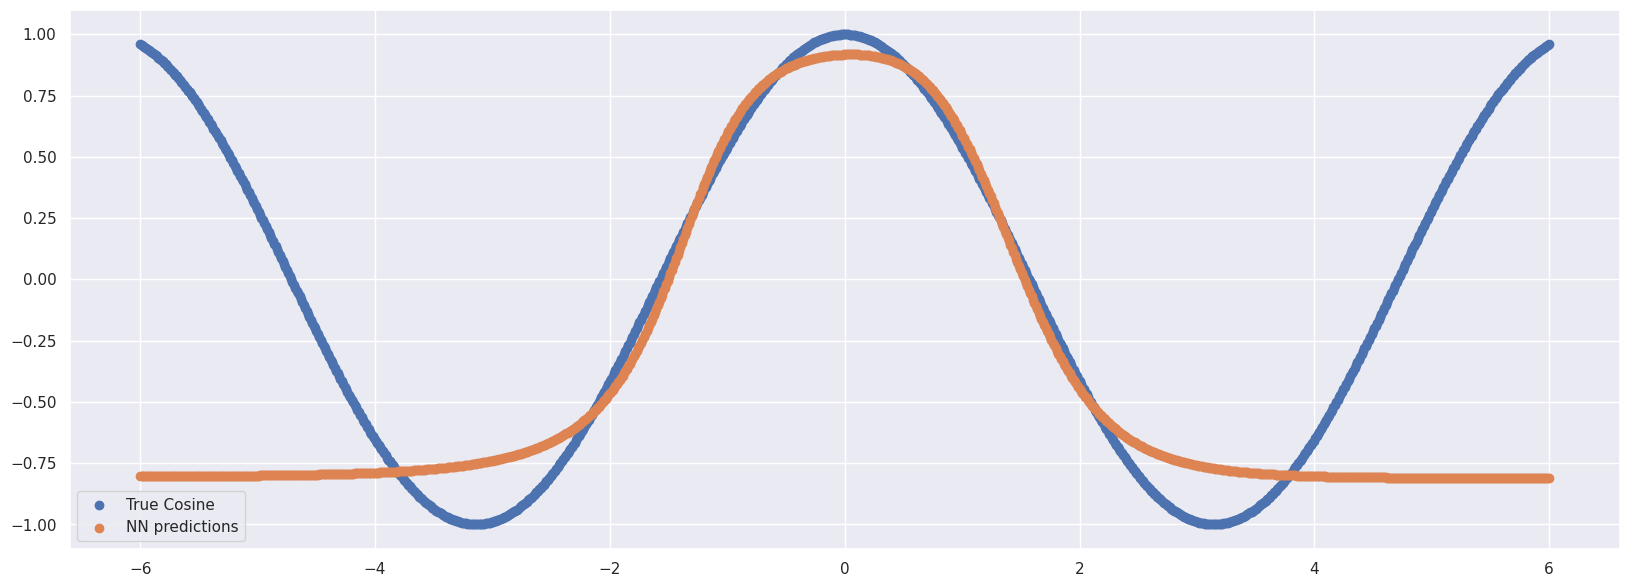

In [ ]:
nn_prediction = NN(X_test.view(-1, 1))
nn_prediction = nn_prediction.detach().numpy()

plt.figure(figsize=(20,7))
plt.scatter(x=X_test, y=Y_test, label='True Cosine');
plt.scatter(x=X_test, y=nn_prediction, label='NN predictions');
plt.legend()

Наследование от класса `nn.Module` позволяет реализовать совместимость нашей модели с интерфейсом `PyTorch`, а также использовать некоторые дополнительные возможности. К примеру, мы можем получить доступ к параметрам модели в матричном виде:

In [ ]:
for param in NN.parameters():
  print('parameter shape: ', param.shape)

parameter shape:  torch.Size([5, 1])
parameter shape:  torch.Size([5])
parameter shape:  torch.Size([5, 5])
parameter shape:  torch.Size([5])
parameter shape:  torch.Size([1, 5])
parameter shape:  torch.Size([1])


## Перенос вычислений на видеокарту

Использование графических ядер - обязательный атрибут работы с глубокими нейронными сетями. Графические ядра позволяют производить быстрые эффективные параллельные вычисления. В `Pytorch` реализован интерфейс переноса вычислений на видеокарту. Для осуществления этого переноса необходимо перенестина видеокарту как параметры модели, так и входные данные.

Прежде всего нужно проверить, доступна ли видеокарта для вычислений. В google-colab для этого нужно в главном меню выбрать вкладку "Среда выполнения", там выбрать команду "Сменить среду выполнения", далее в качестве аппаратного ускорителя выбрать "GPU". После этого можно воспользоваться следующей командой для проверки доступности GPU:

In [ ]:
import torch

# эта команда проверяет, доступен ли GPU
torch.cuda.is_available()

True

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Теперь можем провести вычисления на GPU. Перенос тензоров и модулей на GPU производится при помощи функций `.to(device)`, либо `.cuda()`

**Замечание**

Мы вынуждены продублировать определения основных функций, поскольку после подключения аппаратного ускорителя среда выполнения перезагружается

In [ ]:
import torch
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, dim):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(dim, 5)
        self.tanh1 = nn.Tanh()

        self.fc2 = nn.Linear(5, 5)
        self.tanh2 = nn.Tanh()

        self.fc3 = nn.Linear(5, 1)
        self.tanh3 = nn.Tanh()


    def forward(self, x):

        x = self.fc1(x)
        x = self.tanh1(x)

        x = self.fc2(x)
        x = self.tanh2(x)

        x = self.fc3(x)
        x = self.tanh3(x)
        return x

In [ ]:
NN = Net(1)
NN = NN.to(device) # для переноса на девайс

In [ ]:
NN

Net(
  (fc1): Linear(in_features=1, out_features=5, bias=True)
  (tanh1): Tanh()
  (fc2): Linear(in_features=5, out_features=5, bias=True)
  (tanh2): Tanh()
  (fc3): Linear(in_features=5, out_features=1, bias=True)
  (tanh3): Tanh()
)

In [ ]:
import tqdm
from tqdm.auto import tqdm

def train(model, X, y, criterion, optimizer, num_epoch):
    '''
    args:
        model - модель нейронной сети
        X и y - обучающая выборка
        criterion - функция потерь, взятая из модуля `torch.nn`
        optimizer - оптимизатор, взятый из модуля `torch.optim`
        num_epoch - количество эпох обучения. Т.е. число градиентных шагов,
                    которые будут выполнены для каждого объекта в выборке
    '''
    # цикл по количеству эпох обучения
    for t in tqdm(range(num_epoch)):
        # Вычислим предсказания нашей модели
        y_pred = model(X.to(device))

        # Посчитаем значение функции потерь  на полученном предсказании
        loss = criterion(y_pred, y.to(device))

        # Обнулим посчитанные ранее значения градиентов
        optimizer.zero_grad()

        # Выполним подсчёт новых градиентов
        loss.backward()

        # Выполним шаг градиентного спуска
        optimizer.step()

    return model

Снова заведем данные для косинуса:

In [ ]:
X = torch.normal(mean=torch.zeros((1000, 1)), std= 2)
Y = torch.cos(X)

Обучим нейронную сеть на GPU

In [ ]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(NN.parameters(), lr=1e-2)

NN = train(NN, X, Y, criterion,optimizer, 50)

  0%|          | 0/50 [00:00<?, ?it/s]

Теперь к набору команд `.detach().numpy()` для конвертации тензора в подходящий формат мы должны добавить еще одну команду - `.cpu()`

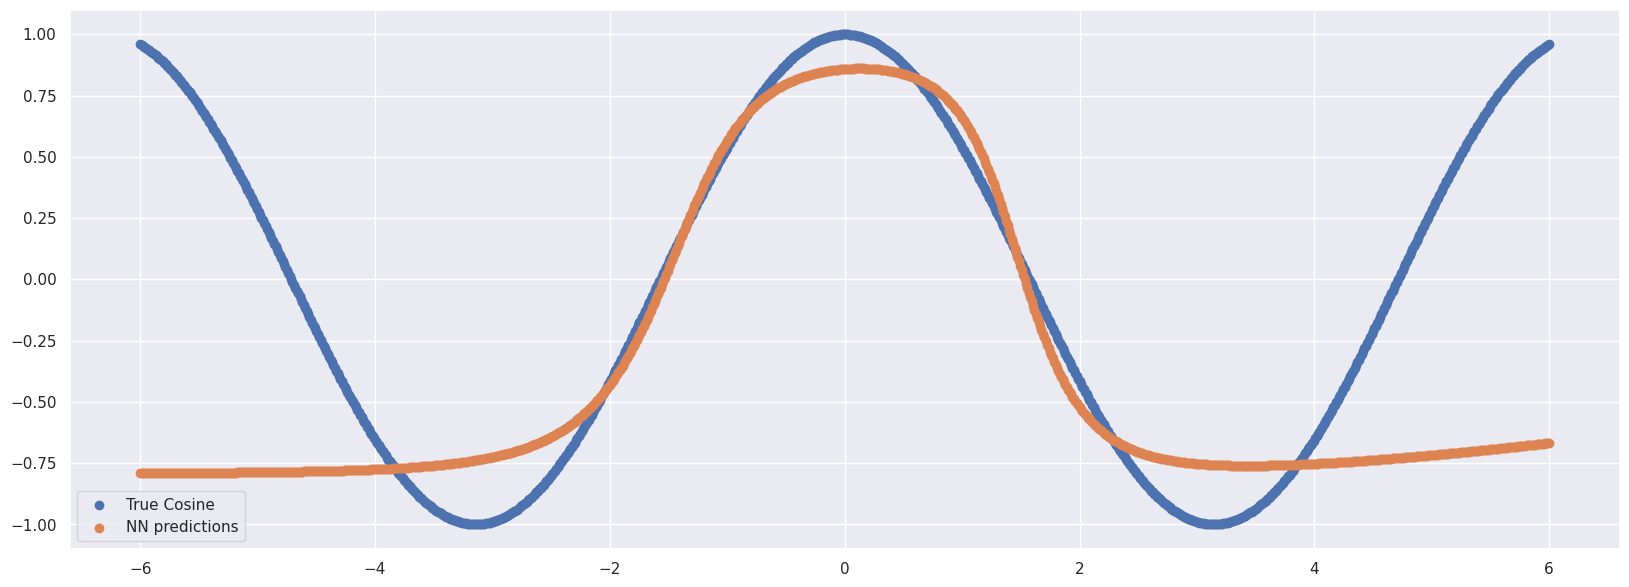

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

X_test = torch.linspace(-6, 6, 1000).to(device)
Y_test = torch.cos(X_test)

nn_prediction = NN(X_test.view(-1, 1))
nn_prediction = nn_prediction.cpu().detach().numpy()

plt.figure(figsize=(20,7))
plt.scatter(x=X_test.cpu(), y=Y_test.cpu(), label='True Cosine');
plt.scatter(x=X_test.cpu(), y=nn_prediction, label='NN predictions');
plt.legend();

# Самостоятельная практика

In [ ]:
import torch
import torch.nn as nn

## `nn.Module`

In [ ]:
class Net(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons, n_out_neurons):
      super(Net, self).__init__()
      self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons)
      self.act1 = nn.Sigmoid()
      self.fc2 = nn.Linear(n_hidden_neurons, n_out_neurons)
      self.act2 = nn.ReLU()

    def forward(self, x):
      x = self.fc1(x)
      x = self.act1(x)
      x = self.fc2(x)
      x = self.act2(x)
      return x

In [ ]:
net = Net(5, 4, 3)

In [ ]:
input_tensor = torch.FloatTensor(5)

In [ ]:
output_tensor = net.forward(input_tensor)
print(output_tensor)

tensor([0.0000, 0.0000, 0.0915], grad_fn=<ReluBackward0>)


### Задача 1

Добавьте в нейронную сеть (в класс `Net`) второй скрытый слой. Для второго скрытого слоя примените гиперболический тангенс `nn.Tanh()` в качестве функции активации.

In [ ]:
class Net(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1,
									n_hidden_neurons_2, n_out_neurons):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.Sigmoid()

        self.fc2 =  # Ваш код
        self.act2 = # Ваш код

        self.fc3 = nn.Linear(n_hidden_neurons_2, n_out_neurons)
        self.act3 = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)

        # Ваш код

        x = self.fc3(x)
        x = self.act3(x)
        return x

### Задача 2

Инициализируйте нейронную сеть, состоящую из трёх входных нейронов, пяти нейронов в первом скрытом слое, трёх нейронов во втором скрытом слое и одного нейрона в выходном слое. Создайте тензор из значений `[1, 44, -7]` и прогоните тензор через сеть. Результат выведите на экран.

In [ ]:
class Net(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1,
									n_hidden_neurons_2, n_out_neurons):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.Sigmoid()

        self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 = nn.Tanh()

        self.fc3 = nn.Linear(n_hidden_neurons_2, n_out_neurons)
        self.act3 = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        x = self.fc3(x)
        x = self.act3(x)
        return x

net = Net(...)               # инициализируйте нейронную сеть
x = torch.Tensor(...)        # инициализируйте тензор
print(...)                   # выведите результат прогонки тензора

### Задача 3

Через нейронную сеть можно прогонять не только отдельные объекты, но и датасеты. Датасеты обрабатываются как тензоры.

Создайте нейронную сеть, содержащую два скрытых слоя: первый содержит `n_hidden_neurons_1`, а второй — `n_hidden_neurons_2`.

После первого скрытого слоя примените гиперболический тангенс в качестве функции активации, после второго — ReLU, после выходного слоя — сигмоиду.

Дополните код прямого распространения в методе `forward()`.

Инициализируйте нейронную сеть, состоящую из десяти входных нейронов, семи нейронов в первом скрытом слое, четырёх нейронов во втором скрытом слое и одного нейрона в выходном слое. Создайте тензор размером 100 на 10, состоящий из случайных вещественных значений. Прогоните тензор через сеть. Результат выведите на экран.

In [ ]:
class Net(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1,
									n_hidden_neurons_2, n_out_neurons):
        super(Net, self).__init__()

        self.fc1 = ...
        self.act1 = ...

        self.fc2 = ...
        self.act2 = ...

        self.fc3 = ...
        self.act3 = ...

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)

        x = ...
        x = ...

        x = ...
        x = ...
        return x

net = Net(...)              # инициализируйте нейронную сеть
x = torch.FloatTensor(...)  # инициализируйте тензор
print(...)                  # выведите результат прогонки тензора

## `Sequential`

Сети прямого распространения создаются альтернативным способом — с помощью контейнера `Sequential`. Этот контейнер строит сеть прямого распространения на основе заданных слоёв. В Sequential уже есть метод forward, в котором входной тензор последовательно проходит через все слои.

При инициализации объекта класса-контейнера Sequential в качестве параметров по очереди передаются слои, которые будут использованы. При этом их порядок изменить уже не получится, нужно будет создавать другой объект.

Перепишем при помощи `Sequential` (вместо `nn.Module`)
```
class Net(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons, n_out_neurons):
      super(Net, self).__init__()
            
            self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons)
            self.act1 = nn.Sigmoid()
            self.fc2 = nn.Linear(n_hidden_neurons, n_out_neurons)        
            self.act2 = nn.ReLU()

    def forward(self, x):
      x = self.fc1(x)
      x = self.act1(x)
      x = self.fc2(x)
      x = self.act2(x)
      return x
```

In [ ]:
n_in_neurons, n_hidden_neurons, n_out_neurons = 5, 4, 3

net = nn.Sequential(
    nn.Linear(n_in_neurons, n_hidden_neurons),
    nn.Sigmoid(),
    nn.Linear(n_hidden_neurons, n_out_neurons),
    nn.ReLU()
)

### Задача 4


Перепишите трёхслойную нейронную сеть из задачи 1 — добавьте в нейронную сеть прямого распространения второй скрытый слой. Для второго скрытого слоя примените гиперболический тангенс `nn.Tanh()` в качестве функции активации.

Задайте конкретные значения для количества нейронов: во входном — `4`, в первом скрытом — `6`, во втором скрытом — `3`, в выходном слое — `1`.

Создайте тензор размером `50` на `4`, состоящий из случайных вещественных значений, и прогоните тензор через сеть.



In [ ]:
n_in_neurons = # Ваш код
n_hidden_neurons_1 = # Ваш код
n_hidden_neurons_2 = # Ваш код
n_out_neurons = # Ваш код

net = nn.Sequential(
    nn.Linear(n_in_neurons, n_hidden_neurons_1),
    nn.Sigmoid(),
		# Ваш код
    nn.Linear(n_hidden_neurons_2, n_out_neurons),
    nn.ReLU()
)

x = ...     # инициализируйте тензор
print(...)  # выведите результат прогонки тензора

### Задача 5

Создайте полносвязную нейронную сеть с произвольным числом скрытых слоёв.  

Количество нейронов в каждом слое задано в списке `n_neurons`. Длина списка не меньше `2`. Каждый элемент списка является числом нейронов в соответствующих слоях. В качестве функций активации для нечётных слоёв используйте сигмоиду `nn.Sigmoid()`, для чётных слоёв — гиперболический тангенс `nn.Tanh()`, входной слой считается нулевым. Для выходного слоя используйте функцию активации `nn.ReLU()`.  

Создайте тензор размером `50` на `20`, состоящий из случайных вещественных значений, и прогоните тензор через сеть.

In [ ]:
import torch
import torch.nn as nn

n_neurons = [20, 16, 12, 8, 4, 2, 1]
net_layers = []

for i in range(1, len(n_neurons) - 1):
		net_layers.append(...) # добавьте полносвязный слой
		if (i+1) % 2 == 0:
				net_layers.append(...) # добавьте функцию активации для чётных слоёв
		else:
				net_layers.append(...) # добавьте функцию активации для нечётных слоёв

net_layers.append(nn.Linear(n_neurons[-2], n_neurons[-1])) # добавление выходного слоя
net_layers.append(...) #

net = nn.Sequential(*net_layers) # такая запись позволяет передавать элементы списка как параметры для инициализации
print(net) # вывод архитектуры сети

x = ...    # инициализируйте тензор
print(...) # выведите результат прогонки тензора

## Функция потерь

### Задача 6

Чтобы решить задачу регрессии с одним скрытым слоем, инициализируйте нейронную сеть прямого распространения, состоящую из пяти входных нейронов, трёх нейронов в скрытом слое и одного нейрона в выходном слое. После каждого слоя добавьте функцию активации `ReLU`.

Создайте тензор x из значений `[-0.23, -0.2, 0.31, -0.9, 0.2]` и прогоните его через сеть. Результат прогонки сохраните в переменной `y_hat`. Создайте тензор y из значения `[0.15]`, в котором будет храниться целевая переменная.

Инициализируйте функцию потерь `MAE` и вычислите значение функции потерь для предсказания модели и целевой переменной.

In [ ]:
import torch
import torch.nn as nn


n_in_neurons = # число входных нейронов
n_hidden_neurons = # число нейронов в скрытом слое
n_out_neurons = # число выходных нейронов

net = nn.Sequential(
    # ваш код
)

x = torch.Tensor(...)
y = torch.Tensor(....)
y_hat = # прогоните x через нейронную сеть

loss = # инициализируйте функцию потерь MAE

print(loss(...))

### Задача 7

Измените сеть из предыдущей задачи так, чтобы она могла решить задачу бинарной классификации. Для этого после выходного слоя замените функцию активации на сигмоиду.  

Создайте тензор x из значений `[-0.23, -0.2, 0.31, -0.9, 0.2]` и прогоните тензор через сеть.

Результат сохраните в переменной `y_hat`. Создайте тензор y из значения [0], в котором будет храниться целевая переменная.  

Инициализируйте функцию потерь бинарной кросс-энтропии и вычислите значение функции потерь для предсказания модели и целевой переменной.
Модель на выходе выдаёт вещественное число от 0 до
1 — «вероятность» принадлежности классу 1. Чтобы перевести это число в класс 0 или 1, сравните его с порогом 0.5: если выход модели больше 0.5, должен быть класс 1, в противном случае — 0.

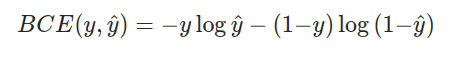

In [ ]:
import torch
import torch.nn as nn


n_in_neurons = 5
n_hidden_neurons = 3
n_out_neurons = 1

net = nn.Sequential(
    nn.Linear(n_in_neurons, n_hidden_neurons),
    nn.ReLU(),
    nn.Linear(n_hidden_neurons, n_out_neurons),
    nn.ReLU()
)

x = torch.Tensor(...)
y = torch.Tensor(....)
y_hat = # прогоните x через нейронную сеть

loss = # инициализируйте функцию потерь бинарной кросс-энтропии

print(loss(...))

print(int(y_hat ... )) # выведите класс, которому принадлежит данный объект, по мнению модели

### Задача 8

Измените сеть из предыдущей задачи так, чтобы она решала задачу многоклассовой классификации. Для этого замените число нейронов на выходе из сети на
3 и после выходного слоя замените функцию активации на `Softmax()`.

Создайте тензор x из значений `[[-0.23, -0.2, 0.31, -0.9, 0.2], [0.23, 0.2, -0.31, 0.9, -0.2]]` и прогоните тензор через сеть. Результат сохраните в переменной `y_hat`. Создайте тензор y из значения [2, 0], в котором будет храниться целевая переменная.  

Инициализируйте функцию потерь кросс-энтропии и вычислите значение функции потерь для предсказания модели и целевой переменной.

Модель на выходе выдаёт «вероятность» принадлежности каждому из классов. Выведите класс методом `argmax(dim=1)`, который для каждого предсказания даёт индекс максимального элемента списка вероятностей — наиболее вероятный класс.

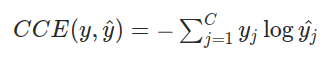

In [ ]:
import torch
import torch.nn as nn


n_in_neurons = 5
n_hidden_neurons = 3
n_out_neurons = 3

net = nn.Sequential(
    nn.Linear(n_in_neurons, n_hidden_neurons),
    nn.ReLU(),
    nn.Linear(n_hidden_neurons, n_out_neurons),
    nn.Sigmoid()
)

x = torch.Tensor(...)
y = torch.LongTensor(....)
y_hat = # прогоните x через нейронную сеть

loss = # инициализируйте функцию потерь категориальной кросс-энтропии

print(loss(...))
print(y_hat)
print(y_hat ... ) # выведите класс, которому принадлежит данный объект, по мнению модели

## Дополнительный материал: метод обратного распространения ошибки

Рассмотрим алгоритм обратного распространения на примере простейшей нейронной сети с двумя входами (`i1`, `i2`), двумя скрытыми (`h1`, `h2`) и двумя выходными (`o1`, `o2`) нейронами. При этом на скрытые и выходные нейроны еще действуют и смещения (`b1` и `b2`), которые в англоязычном варианте называют `bias`.

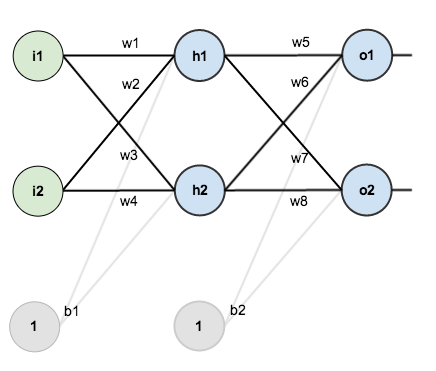

Основной целью backpropagation применительно к нейронным сетям является оптимизация весов связей между нейронами для того, чтобы проектируемая нейронная сеть смогла обучиться правильно отображать произвольные входные данные в нужные значения выходов. В данном примере обучающая выборка будет состоять всего из одного набора данных, при входных значениях которого 0.05 и 0.10 требуется, чтобы нейронная сеть выдавала значения 0,01 и 0,99, соответственно.

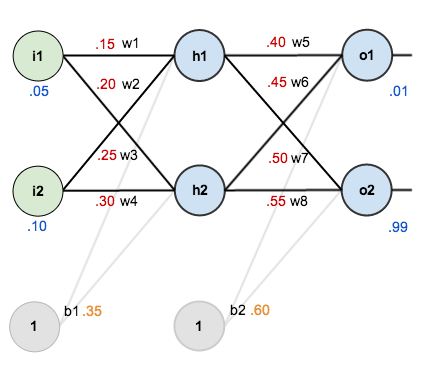

### Прямой ход (Forward Pass)

Настройка любой нейронной сети всегда начинается с прямого распространения входных сигналов по слоям нейронной сети. При этом на первом этапе требуется выяснить, на что в данный момент способна нейронная сеть и какие значения выходов она может предсказать для входных сигналов $x_1 = 0.05$ и $x_2 = 0.1$ с учетом сгенерированных случайным образом значений весовых коэффициентов и смещений. Для этого требуется поступившие входные значения передать вперед по слоям сети: от входного слоя к скрытому, и от скрытого к выходному.

1. Для вычисления значений выходов каждого из нейронов скрытого слоя необходимо для каждого из них вычислить взвешенную сумму поступающих на него сигналов и применить к ней функцию активации.
2. Взвешенная сумма входных сигналов для нейрона $h_1$ может быть вычислена по следующей формуле:


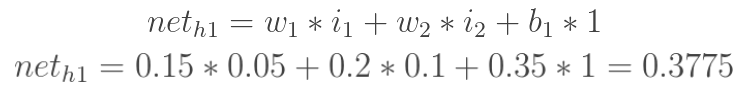

3. Выходное значение нейрона $h_1$ можно получить, применив функцию активации к выходу его сумматора, то есть

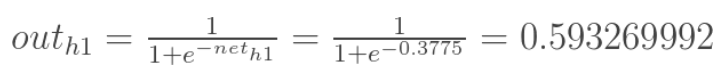

4. Выполнив аналогичные операции, мы получим значение выхода для нейрона $h_2$:

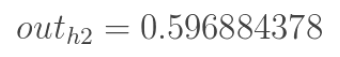

На следующем этапе необходимо выполнить распространение сигналов от скрытого слоя к выходному, выполняя вычисления, аналогичные вышеописанным, и используя выходы нейронов скрытого слоя в качестве входных данных.


1. Так, для нейрона выходного слоя $o_1$ будут получены следующие результаты:


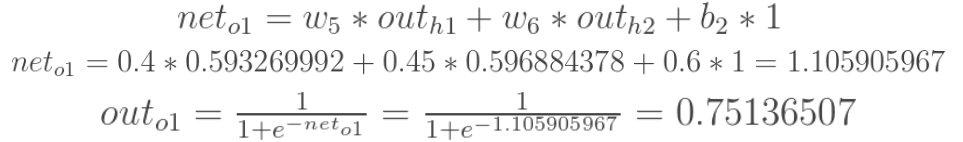

2. Выполняя аналогичные расчеты для нейрона $o_2$, мы получим:


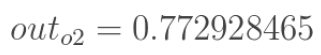

На этом процесс прямого распространения сигналов на данной итерации расчета можно считать законченным.

### Вычисление обобщенной ошибки

Вычислив предсказанные нейронной сетью значения ее выходов (output), и зная их желаемые целевые значения (target), можно вычислить ошибку предсказания каждым из выходных нейронов. А затем, используя квадратичную функцию ошибки, суммировать их для получения обобщенной ошибки настройки сети на данном этапе расчета:

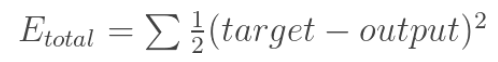

На данный момент выход нейрона $o_1$ равен 0,75136507, а его желаемое (целевое) значение должно быть 0.01. Поэтому ошибка предсказания нейрона $o_1$ будет:

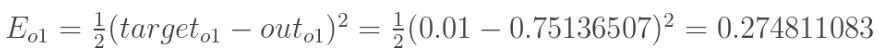

Вспоминая, что желаемое (целевое) значение выхода $o_2$ должно быть 0.99, а текущее значение равно 0.772928465, можно вычислить ошибку предсказания нейрона $o_2$, которая будет равна:

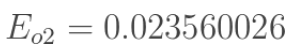

Общая ошибка предсказания нейронной сети представляет собой сумму ошибок предсказания всех выходных нейронов и равна:

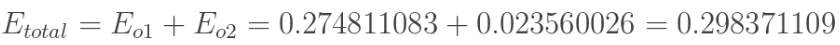

### Обратное распространение ошибки

Целью обратного распространения ошибки (backpropagation) является обновление весов связи между всеми нейронами сети так, чтобы они привели к тому, чтобы фактический результат стал ближе к желаемому (целевому) результату, минимизировав тем самым ошибку предсказания, как для каждого выходного нейрона, так и сети в целом. Работа алгоритма backpropagation идет в обратном направлении: сначала на выходном слое, а затем на скрытом.

#### Обновление весов выходного слоя

На выходном слое нейронной сети присутствуют связи с весами $w_5$ и $w_6$ к нейрону $o_1$, а также связи с весами $w_7$ и $w_8$ к нейрону $o_2$. Они поступают с выходов нейронов скрытого слоя. Кроме того, на оба выходных нейрона оказывает влияние связь от смещения $b_2$.

Процесс изменения весов начнем с $w_5$. Чтобы знать как изменение w5 влияет на общую ошибку сети, надо вычислить частную производную от $E_total$ по $w_5$. Если функцию ошибки представить как сложную функцию, то тогда, используя правило дифференцирования сложных функций (*chain rule*), можно получить:

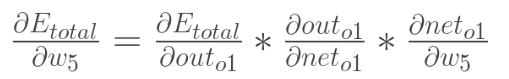

Визуально это можно представить следующим образом:

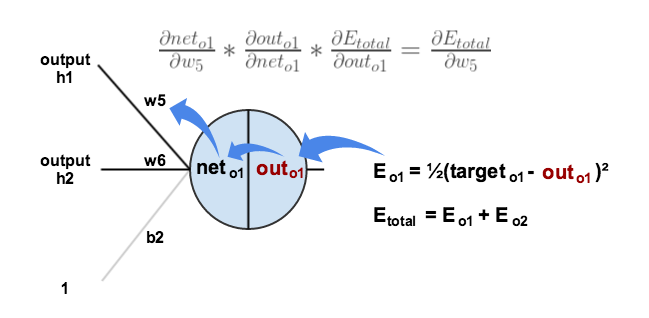

Для того чтобы решить поставленную задачу по обновлению значения $w_5$, нам предстоить определить каждую из составлящих данного выражения. Для этого надо выполнить следующую последовательность действий:

1. Первое, что требуется выяснить, это как изменение выходного сигнала $out_o1$ влияет на общую ошибку работы сети. Так как


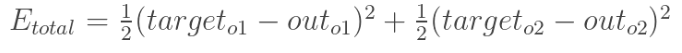

то

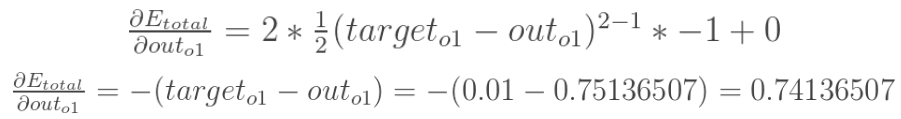

Надо отметить, что когда берется частная производная от полной ошибки относительно $out_o1$, то величина

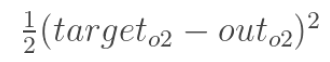

становится равной нулю, потому что $out_{o1}$ не влияет на нее. Это означает, что мы берем производную от константы, которая равна нулю.

2. На следующем этапе необходимо для нейрона $o1$ вычислить частную производную его выхода $out_{o1}$ по отношению к выходу его сумматора, формирующего взвешенную сумму его входов, а именно $net_{o1}$.
Особенность логистической функции (сигмоида) состоит в том, что частная производная от этой функции может быть выражена через саму эту функцию, а именно:

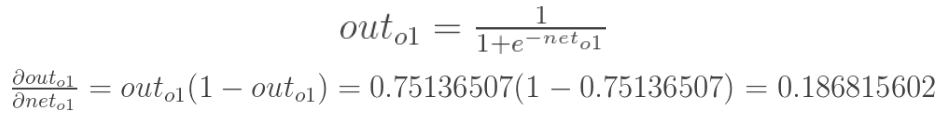

3. И, наконец, последнее, что осталось оценить, так это степень влияния изменения $w_5$ на величину взвешенной суммы $net_{o1}$, то есть

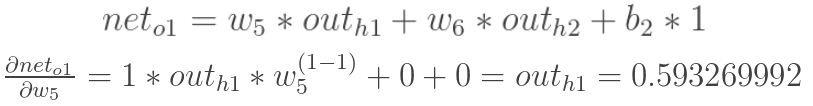

После выполнения всех приведенных выше вычислений, появляется возможность объединить их в одно выражение и провести расчет, а именно:

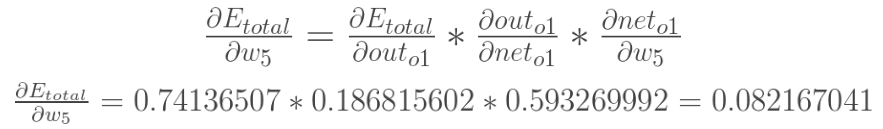

Вернемся к настройке весов, а именно коэффициенту $w_5$. Чтобы уменьшить его воздействие на общую ошибку сети, мы должны вычесть полученное значение из текущего веса. Возможно, это значение будет умножено на некоторую скорость обучения $η$.

Выбор величиеы этого параметра представляет собой отдельную задачу, так как он влияет на качество и сходимость процедуры настройки нейронной сети. Принимая значения $η$ равным 0.5, скоректированное на этом шаге значение $w_5$ будет:

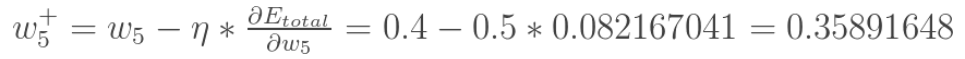

Выполняя аналогичные операции, можно получить скоррктированные значения для всех других весов выходного слоя:

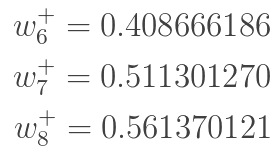

Обратите внимание, что мы выполняем фактические обновления в нейронной сети после того, как у нас появились новые веса, ведущие к нейронам скрытого слоя (т. е. мы используем исходные веса, а не обновленные веса, когда мы продолжаем алгоритм backpropagation ниже).



### Обновление весов скрытого слоя

Сделав шаг назад, мы от выходного слоя перейдем к скрытому с целью обновления значений весов $w_1$, $w_2$, $w_3$ и $w_4$. Остановимся на рассмотрении процесса обновления веса $w_1$ и выясним степень его влияния на общую ошибку настройки сети:

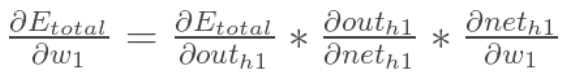

Визуально это может быть представлено следующим образом:

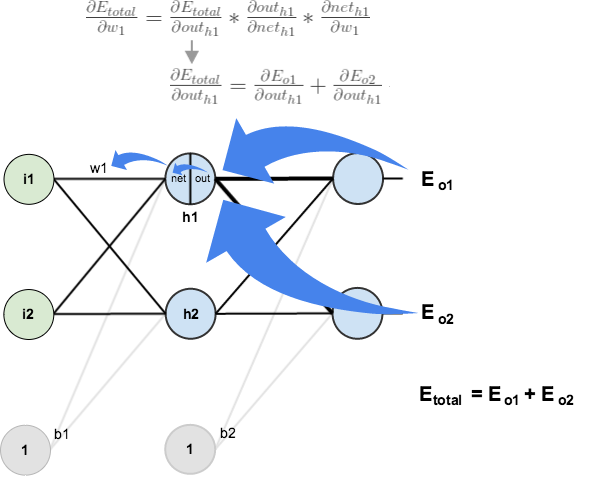

Используем подход, аналогичный выходному слою, но его отличие будет в том, что выходы каждого нейрона скрытого слоя влияют сразу на несколько нейронов выходного слоя. Так, нейрон $h_1$ влияет на ошибку предсказания нейронов $o_1$ и $o_2$, а это сказывается и на общей ошибке сети.

Так как изменение сигнала $out_{h1}$ вызывает изменение как $out_{o1}$, так и $out_{o2}$, то для оценки степени его влияния на общую ошибку сети необходимо вычислить

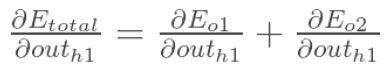

1. Начнем рассмотрение этого выражения с первого слагаемого, которое можно представить в виде:

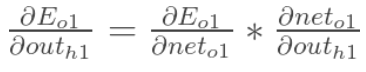

Первый сомножитель этого выражения можно рассчитать на основе двух полученных ранее соотношений, а именно

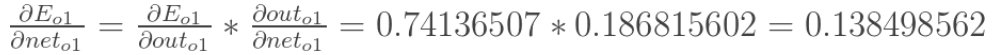

Что касается второго сомножителя, то его можно вычислить, используя

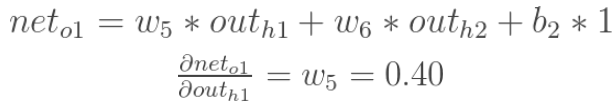

После подстановки полученных значений в исходное выражение получим:

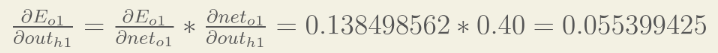

2. Поступая аналогично со вторым слагаемым, мы получим:

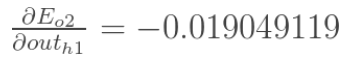

3. Откуда следует, что

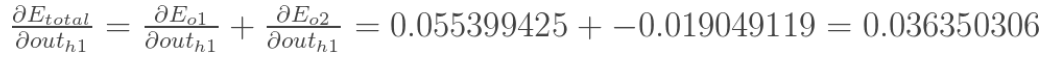

Вспомним, что мы рассмотриваем процесс обновления веса $w_1$ и выясням степень его влияния на общую ошибку настройки сети:

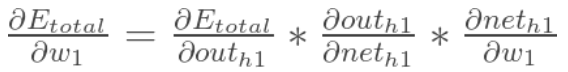

Теперь, когда мы разобрались с первым сомножителем этого выражения, требуется разобраться и с двумя оставшимися.

1. Так, например, второй сомножитель может быть определен следующим образом

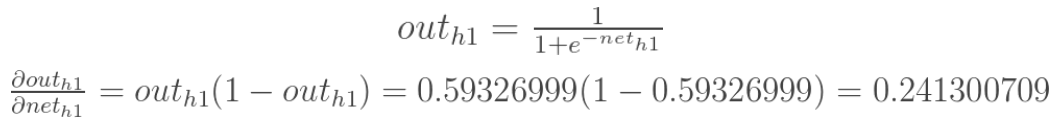

А третий можно определить, воспользовавшись следующими выражениями

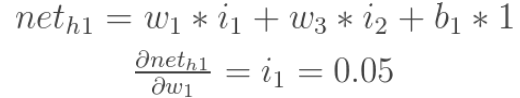

Объединяя все полученные выше соотношения, можно получить окончательное выражение для частной производной от общей ошибки сети по весовому коэффициенту $w_1$:

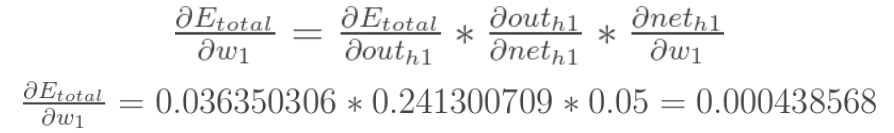

После выполнения всех этих преобразований и расчетов, у нас появляется реальная возможность обновить значения весового коэффициента $w_1$:

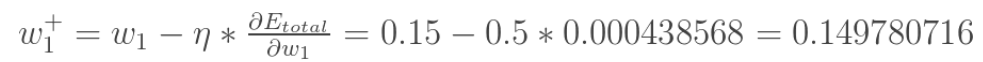

Повторяя все проведенные выше расчеты для $w_2$, $w_3$ и $w_4$, можно получить:

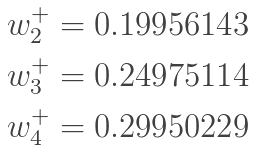

Наконец, мы обновили все наши веса!

При подаче на вход сети вектора исходных данных (0.05; 0.10), ошибка сети в результате прямого распространения составляла 0.298371109. В результате одной итерации алгоритма backpropagation общая ошибка предсказания сети теперь составляет 0.291027924. Может показаться, что это не очень много, но после повторения этого процесса, например, 10 000 раз ошибка падает до 0.0000351085.